# Chương 4. HỌC MÁY

### Thuật toán K-Means

Bài toán phân khúc khách hàng thường không có nhãn sẵn, nên ta không biết mỗi khách hàng thuộc nhóm nào. Thuật toán cần tự tìm ra các cụm dựa trên những đặc điểm tương đồng như hành vi, độ tuổi, thu nhập hay tần suất giao dịch. K-Means được sử dụng phổ biến vì đơn giản, dễ triển khai và hiệu quả khi dữ liệu có cấu trúc tương đối đơn giản.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Đọc dữ liệu
cus = pd.read_csv('../data/customer.csv')
cus_numeric = cus.select_dtypes(include=['int', 'float'])
cus_clean = cus_numeric.dropna(axis=1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cus_clean)


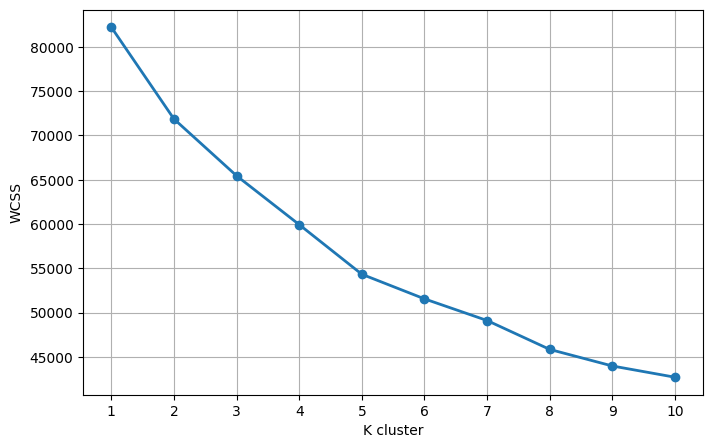

In [22]:
# Elbow Method để tìm số cụm tối ưu
wcss = []
K = range(1, 11)  # thử từ 1 đến 10 cụm

for k in K:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42)
    kmeans_tmp.fit(X_scaled)
    wcss.append(kmeans_tmp.inertia_)  # inertia_ = WCSS

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o', linestyle='-', linewidth=2)
plt.xlabel('K cluster')
plt.ylabel('WCSS')
plt.xticks(K)
plt.grid(True)
plt.show()

In [23]:
# Chọn số cụm (ví dụ k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)
# Giảm chiều dữ liệu về 2D để trực quan bằng PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
# Tính lại tọa độ centroid trên không gian PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)
print(centroids_pca)

[[ 0.04408103 -0.79592494 -0.09171967  0.02340066 -0.11684509]
 [-0.78446033  0.75952739  0.08757171 -0.01024018  0.09732981]
 [ 3.00764463  0.63734287  0.07325512 -0.06829446  0.15165293]]


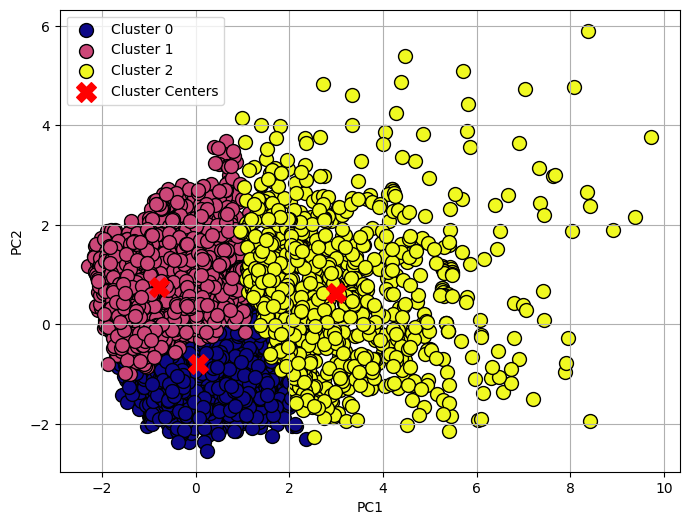

In [24]:
# Vẽ biểu đồ kết quả phân cụm
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(sorted(unique_labels), colors):
    label_name = f'Cluster {label}' if label != -1 else 'Noise'
    color = 'k' if label == -1 else color
    plt.scatter(
        X_pca[labels == label, 0], 
        X_pca[labels == label, 1],
        edgecolors='black',       
        linewidths=1.0,      
        c=[color], 
        label=label_name, 
        s=100
    )

plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    c='red', 
    s=200, 
    marker='X', 
    label='Cluster Centers'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()
